In [ ]:
import pandas as pd

df = pd.read_excel("/content/drive/MyDrive/Alzheimer_AI_Virtual_Screening/Final_Docking_Dataset.xlsx")

df.head()

,Ligand,Binding Energy (kcal/mol),PubChem CID,Molecular Weight,XLogP,TPSA,H Bond Donor,H Bond Acceptor,Rotatable Bonds
0,EGCG,-11.972,65064,458.4,1.2,197.0,8,11,4
1,Donepezil,-11.771,3152,379.5,4.3,38.8,0,4,6
2,Demethoxycurcumin,-10.948,5469424,338.4,3.3,83.8,2,5,7
3,Curcumin,-10.932,969516,368.4,3.2,93.1,2,6,8
4,Bisdemethoxycurcumin,-10.749,5315472,308.3,3.3,74.6,2,4,6


Check Molecular Weight

In [ ]:
df["MW Pass"] = df["Molecular Weight"] <= 500

Check LogP

In [ ]:
df["LogP Pass"] = df["XLogP"] <= 5

Check H Bond Donor

In [ ]:
df["HBD Pass"] = df["H Bond Donor"] <= 5

Check H Bond Acceptor

In [ ]:
df["HBA Pass"] = df["H Bond Acceptor"] <= 10

Count Violations

In [ ]:
df["Violations"] = (
    (~df["MW Pass"]).astype(int)
    + (~df["LogP Pass"]).astype(int)
    + (~df["HBD Pass"]).astype(int)
    + (~df["HBA Pass"]).astype(int)
)

Determine Drug-Likeness

In [ ]:
df["Lipinski"] = df["Violations"].apply(
    lambda x: "Pass" if x <= 1 else "Fail"
)

View Results

In [ ]:
df[
    [
        "Ligand",
        "Molecular Weight",
        "XLogP",
        "H Bond Donor",
        "H Bond Acceptor",
        "Violations",
        "Lipinski"
    ]
]

,Ligand,Molecular Weight,XLogP,H Bond Donor,H Bond Acceptor,Violations,Lipinski
0,EGCG,458.40,1.2,8,11,2,Fail
1,Donepezil,379.50,4.3,0,4,0,Pass
2,Demethoxycurcumin,338.40,3.3,2,5,0,Pass
3,Curcumin,368.40,3.2,2,6,0,Pass
4,Bisdemethoxycurcumin,308.30,3.3,2,4,0,Pass
5,Hesperidin,610.60,-1.1,8,15,3,Fail
6,Rosmarinic acid,360.30,2.4,5,8,0,Pass
7,Baicalein,270.24,1.7,3,5,0,Pass
8,Ellagic acid,302.19,1.1,4,8,0,Pass
9,Chrysin,254.24,2.1,2,4,0,Pass


In [ ]:
df.to_excel("Lipinski_Analysis.xlsx", index=False)

Pie Chart

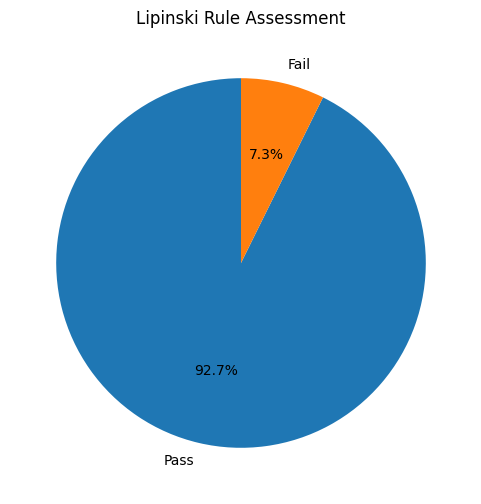

In [ ]:
import matplotlib.pyplot as plt

counts = df["Lipinski"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Lipinski Rule Assessment")

plt.show()